In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
df = pd.read_csv("Cardio/medical_examination.csv",  sep=";")

print(df.head())

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


In [14]:
bmi = df['weight'] / ((df['height'] / 100) ** 2)
# print(bmi.head())
df['overweight'] = (bmi > 25).astype(int)

print("add new columns overweight: ")
print(df[['weight', "height", 'overweight']])


add new columns overweight: 
       weight  height  overweight
0        62.0     168           0
1        85.0     156           1
2        64.0     165           0
3        82.0     169           1
4        56.0     156           0
...       ...     ...         ...
69995    76.0     168           1
69996   126.0     158           1
69997   105.0     183           1
69998    72.0     163           1
69999    72.0     170           0

[70000 rows x 3 columns]


In [15]:
df["cholesterol"] = (df["cholesterol"] > 1).astype(int)
df["gluc"] = (df["gluc"] > 1).astype(int)

print("normalize value in cholesterol and glucose :")
print(df.head())

normalize value in cholesterol and glucose :
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            0     0      0   
1   1  20228       1     156    85.0    140     90            1     0      0   
2   2  18857       1     165    64.0    130     70            1     0      0   
3   3  17623       2     169    82.0    150    100            0     0      0   
4   4  17474       1     156    56.0    100     60            0     0      0   

   alco  active  cardio  overweight  
0     0       1       0           0  
1     0       1       1           1  
2     0       0       1           0  
3     0       1       1           1  
4     0       0       0           0  


In [16]:
def draw_cat_plot():

    df_cat = pd.melt(
        df, 
        id_vars=["cardio"],
        value_vars=["cholesterol", "gluc", "smoke", "alco", "active", "overweight"]
    )

    df_cat = df_cat.groupby(["cardio", "variable", "value"]).size().reset_index(name="total")

    fig = sns.catplot(
        data=df_cat,
        x = "variable",
        y = "total",
        hue = "value",
        col = "cardio",
        kind = "bar"
    ).fig

    fig.savefig("catplot.png")
    return fig

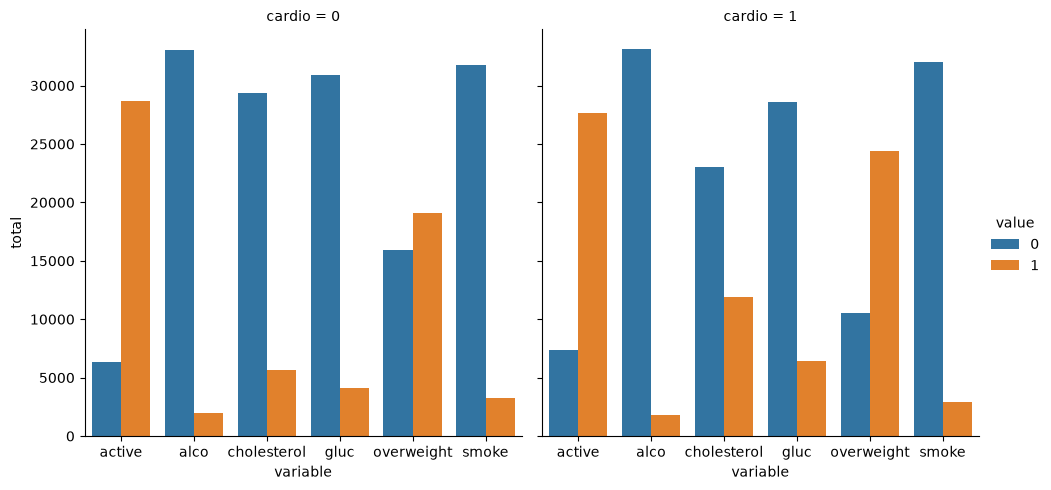

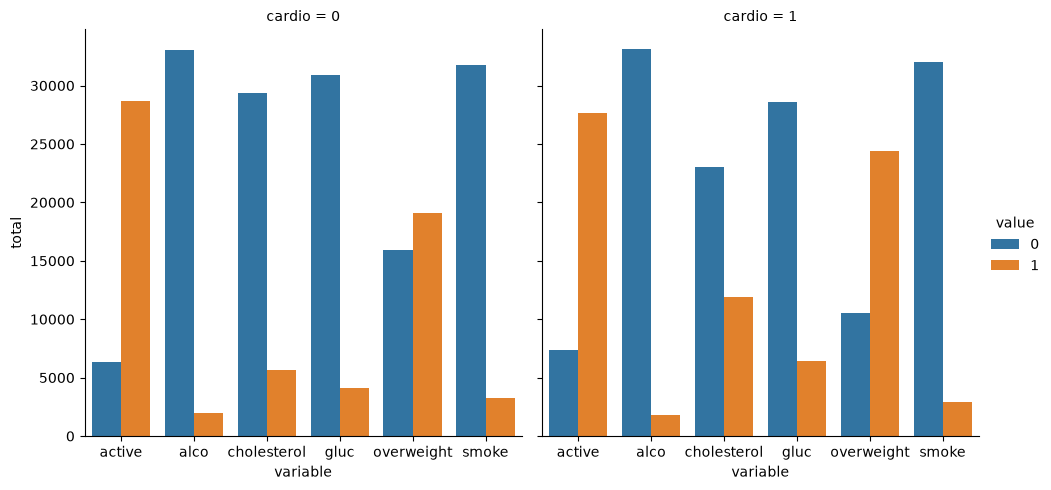

In [17]:
draw_cat_plot()

In [24]:
def draw_heat_map():
    df_heat = df[
        (df['ap_lo'] <= df['ap_hi']) &
        (df['height'] >= df['height'].quantile(0.025)) &
        (df['height'] <= df['height'].quantile(0.975)) &
        (df['weight'] >= df['weight'].quantile(0.025)) &
        (df['weight'] <= df['weight'].quantile(0.925)) 
    ]

    corr = df_heat.corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize = (12,10))
    sns.heatmap(
        corr, 
        mask=mask,
        annot=True,
        fmt=".1f",
        center=0,
        vmin=-0.1,
        vmax=0.3,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.5},
        ax=ax
    )

    fig.savefig('heatmap.png')
    return fig

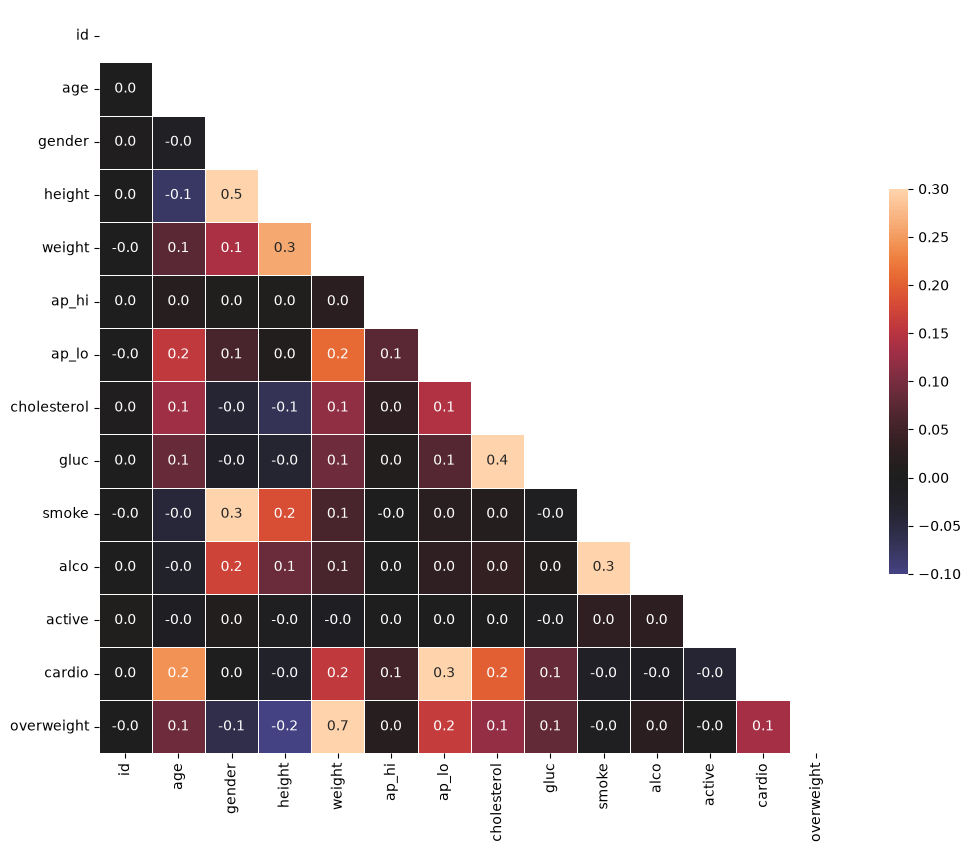

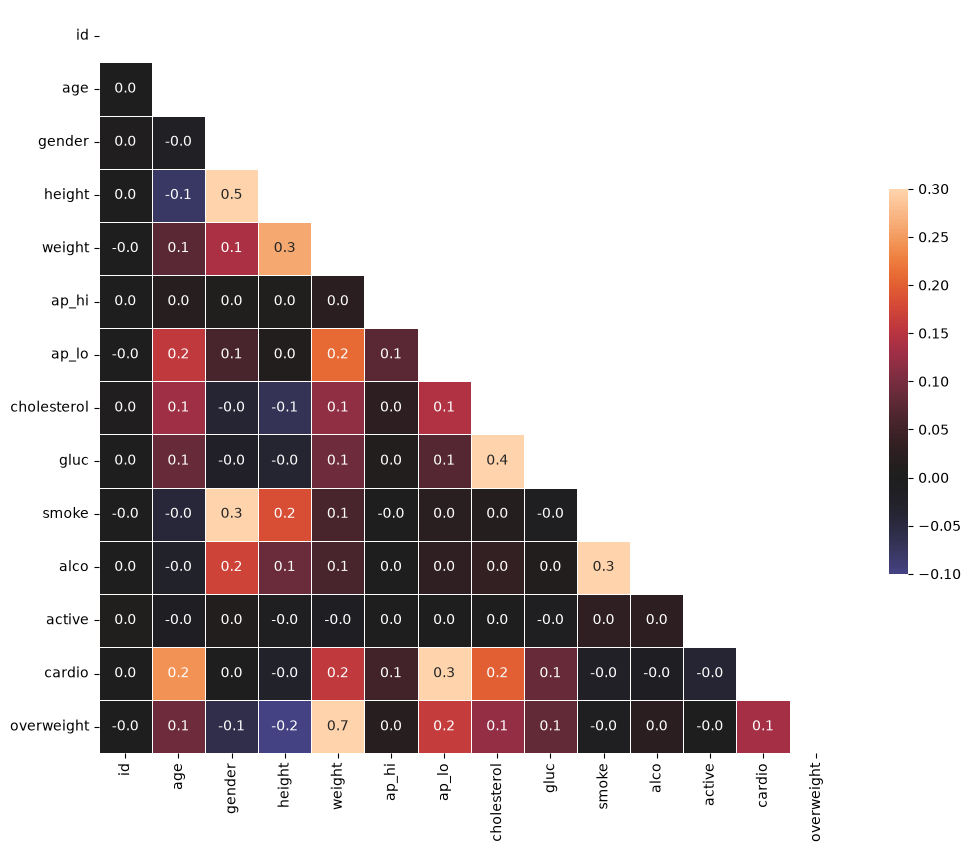

In [25]:
draw_heat_map()